## Statistical Analysis

In [10]:
import ast
import json
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
import scikit_posthocs as sp
from scipy import stats


pd.set_option('display.max_rows', None)


TS_COL = 'time:timestamp'
CASE_COL = 'case:concept:name'
ACTIVITY_COL = 'concept:name'


DATASET_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/')

DATASET_LIST = [
    'BPIC_12',
    'BPIC_12_A',
    'BPIC_12_O',
    'BPIC_12_W',
    'BPIC_13_C',
    'BPIC_13_I',
    'BPIC_15_1',
    'BPIC_15_2',
    'BPIC_15_3',
    'BPIC_15_4',
    'BPIC_15_5',
    'BPIC_18_C',
    'BPIC_18_G',
    'BPIC_18_P',
    'BPIC_20_DD',
    'BPIC_20_ID',
    'BPIC_20_PTC',
    'BPIC_20_RFP',
    'BPIC_20_TPD',
    'Helpdesk',
    'Hospital_Billing',
    'Sepsis',
    'Traffic_Fines',
]

U_THEILS_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stats/theils_u.csv'
)

SAMPLES_NUM_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stats/samples_num.csv'
)

N_GRAMS_JSON_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/ngram/results.json'
)

NGRAM_PREDICTIONS_DICT = json.load(N_GRAMS_JSON_PATH.open())

PREFIX_LEN_JSON_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/prefix_len/results.json'
)

PREFIX_LEN_PREDICTIONS_DICT = json.load(PREFIX_LEN_JSON_PATH.open())

PREDICTIONS_JSON_PATH = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/results.json'
)

PREDICTIONS_DICT = json.load(PREDICTIONS_JSON_PATH.open())

START_EVENTS_JSON = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/start_events.json'
)

START_EVENTS = json.load(START_EVENTS_JSON.open())

PREDICTIONS_BASE_FOLDER = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/baseline/'
)

PREFIX_LEN_BASE_FOLDER = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/prefix_len/'
)

N_GRAM_BASE_FOLDER = Path(
    'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/ngram/'
)


def get_dataset_path(dataset_name):
    dataset_path = DATASET_FOLDER / f'{dataset_name}.xes'
    return dataset_path


def get_stream_df(dataset_path):
    original_stream_df = pm4py.read_xes(str(dataset_path))
    original_stream_df[TS_COL] = pd.to_datetime(original_stream_df[TS_COL])

    original_stream_df = original_stream_df.sort_values(
        by=[CASE_COL, TS_COL]
    ).reset_index(drop=True)

    return original_stream_df


def get_prefix_df(df, prefix_length):
    records = []
    for _, group in df.groupby(CASE_COL):
        activities = group[ACTIVITY_COL].tolist()

        for i in range(len(activities) - prefix_length):
            prefix = tuple(activities[i : i + prefix_length])
            next_activity = activities[i + prefix_length]
            records.append(
                {
                    'prefix': str(prefix),
                    'next_activity': next_activity,
                }
            )
    prefix_df = pd.DataFrame(records)

    return prefix_df


def get_u_values():
    u_values = pd.read_csv(U_THEILS_PATH).set_index('dataset_name').sort_index()
    u_values.columns = u_values.columns.astype(int)
    return u_values


def get_samples_nums():
    df = pd.read_csv(SAMPLES_NUM_PATH, index_col='dataset_name')
    df.columns = df.columns.astype(int)
    return df.sort_index().sort_index(axis=1)


In [218]:
def plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=None,
    x_label='Prefix Length',
    y_labels=None,
    samples_df=None,
):
    y_vars = y_vars or ['f1_scores', 'u_vals']

    y_labels = y_labels or ['Macro F1', "Theil's U"]

    n_plots = len(plot_data)
    n_cols = min(6, n_plots)
    n_rows = int(np.ceil(n_plots / 6))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 6 * n_rows),
    )

    axes = np.array(axes).reshape(-1) if n_plots > 1 else np.array([axes])

    for idx, (dataset_name, data) in enumerate(plot_data.items()):
        x_vals = data.get(x_var, [])
        ax = axes[idx]

        # Sample counts
        if samples_df is not None and dataset_name in samples_df.index:
            event_counts = []
            for xv in x_vals:
                try:
                    event_counts.append(int(samples_df.loc[dataset_name, int(xv)]))
                except Exception:
                    event_counts.append(0)
            event_counts = np.array(event_counts, dtype=float)
            max_cnt = event_counts.max() if event_counts.size else 0
            if max_cnt > 0:
                event_counts_norm = event_counts / max_cnt
            else:
                event_counts_norm = event_counts  # zeros
            ax.bar(
                x_vals,
                event_counts_norm,
                color='gray',
                alpha=0.15,
                width=0.6,
                zorder=0,
            )

        for y_var, y_label in zip(y_vars, y_labels, strict=True):
            if y_var not in data:
                continue

            y_vals = data.get(y_var, [])

            if y_vals:
                ax.plot(
                    x_vals,
                    y_vals,
                    marker='o',
                    label=y_label,
                    linewidth=2,
                    markersize=8,
                    zorder=1,
                )

        ax.set_xlabel(x_label)
        ax.set_ylabel('Score')
        ax.set_title(dataset_name)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        ax.set_xticks(x_vals)

    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

### Chi-Squared Test of Independence

The Logic: Create a contingency table where rows are the last $n$ events (e.g., "A $\rightarrow$ B") and columns are the predicted next events.

If the Chi-squared $p$-value is low, it proves that the specific prefix significantly influences which event comes next

In [64]:
dataset_name = 'BPIC_20_ID'

# dataset_name = 'BPIC_13_I'

# dataset_name = 'BPIC_13_C'

dataset_path = get_dataset_path(dataset_name)
stream_df = get_stream_df(dataset_path)

parsing log, completed traces :: 100%|██████████| 6449/6449 [00:02<00:00, 2839.41it/s]


In [55]:
prefix_length = 3

prefix_df = get_prefix_df(stream_df, prefix_length=prefix_length)

In [56]:
from scipy.stats import chi2_contingency


def run_ovr_statistical_tests(prefix_df, alpha=0.05):
    unique_activities = prefix_df['next_activity'].unique()
    results = []

    # Bonferroni correction
    adjusted_alpha = alpha / len(unique_activities)

    print(f'Using Adjusted Alpha: {adjusted_alpha:.5f}')

    for activity in unique_activities:
        # Create a binary target column
        temp_df = prefix_df.copy()
        temp_df['target'] = temp_df['next_activity'].apply(
            lambda x: 'Target' if x == activity else 'Other'
        )

        # Create r x 2 table
        ct = pd.crosstab(temp_df['prefix'], temp_df['target'])

        # Optimization: Remove prefixes that only appear once overall
        ct = ct[ct.sum(axis=1) > 1]

        if ct.empty:
            print(f'Skipping {activity} due to insufficient data')
            continue

        chi2, p, dof, expected = chi2_contingency(ct)

        is_significant = p < adjusted_alpha
        results.append(
            {'activity': activity, 'p_value': p, 'significant': is_significant}
        )

    return pd.DataFrame(results)

In [59]:
ovr_results = run_ovr_statistical_tests(prefix_df, alpha=0.01)

ovr_results

Using Adjusted Alpha: 0.00250


,activity,p_value,significant
0,Accepted,1.258827e-73,True
1,Completed,1.386215e-95,True
2,Queued,1.891799e-12,True
3,Unmatched,9.973324e-01,False


### Theil's U

In [ ]:
import pandas as pd
from scipy.stats import entropy
from sklearn.metrics import mutual_info_score


def calculate_theils_u(prefix_df):
    x = prefix_df['next_activity']
    y = prefix_df['prefix']

    # 1. Mutual Information: I(X, Y)
    mi = mutual_info_score(x, y)

    # 2. Entropy: H(X)
    prob_x = x.value_counts(normalize=True)
    h_x = entropy(prob_x)

    # 3. Theil's U: U(X|Y) = I(X, Y) / H(X)
    return mi / h_x if h_x > 0 else 1.0

In [ ]:
results = []

for dataset_name in DATASET_LIST:
    dataset_path = get_dataset_path(dataset_name)
    stream_df = get_stream_df(dataset_path)

    for prefix_len in [3, 4, 5, 6, 7]:
        prefix_df = get_prefix_df(stream_df, prefix_length=prefix_len)
        u_value = calculate_theils_u(prefix_df)

        results.append(
            {
                'dataset_name': dataset_name,
                'prefix_length': prefix_len,
                'theils_u': u_value,
                'samples_num': len(prefix_df),
            }
        )

results_df = pd.DataFrame(results)

In [ ]:
theils_df = results_df.pivot(
    index='dataset_name', columns='prefix_length', values='theils_u'
).sort_index()

theils_df.to_csv(U_THEILS_PATH)

samples_num_df = results_df.pivot(
    index='dataset_name', columns='prefix_length', values='samples_num'
).sort_index()

samples_num_df.to_csv(SAMPLES_NUM_PATH)

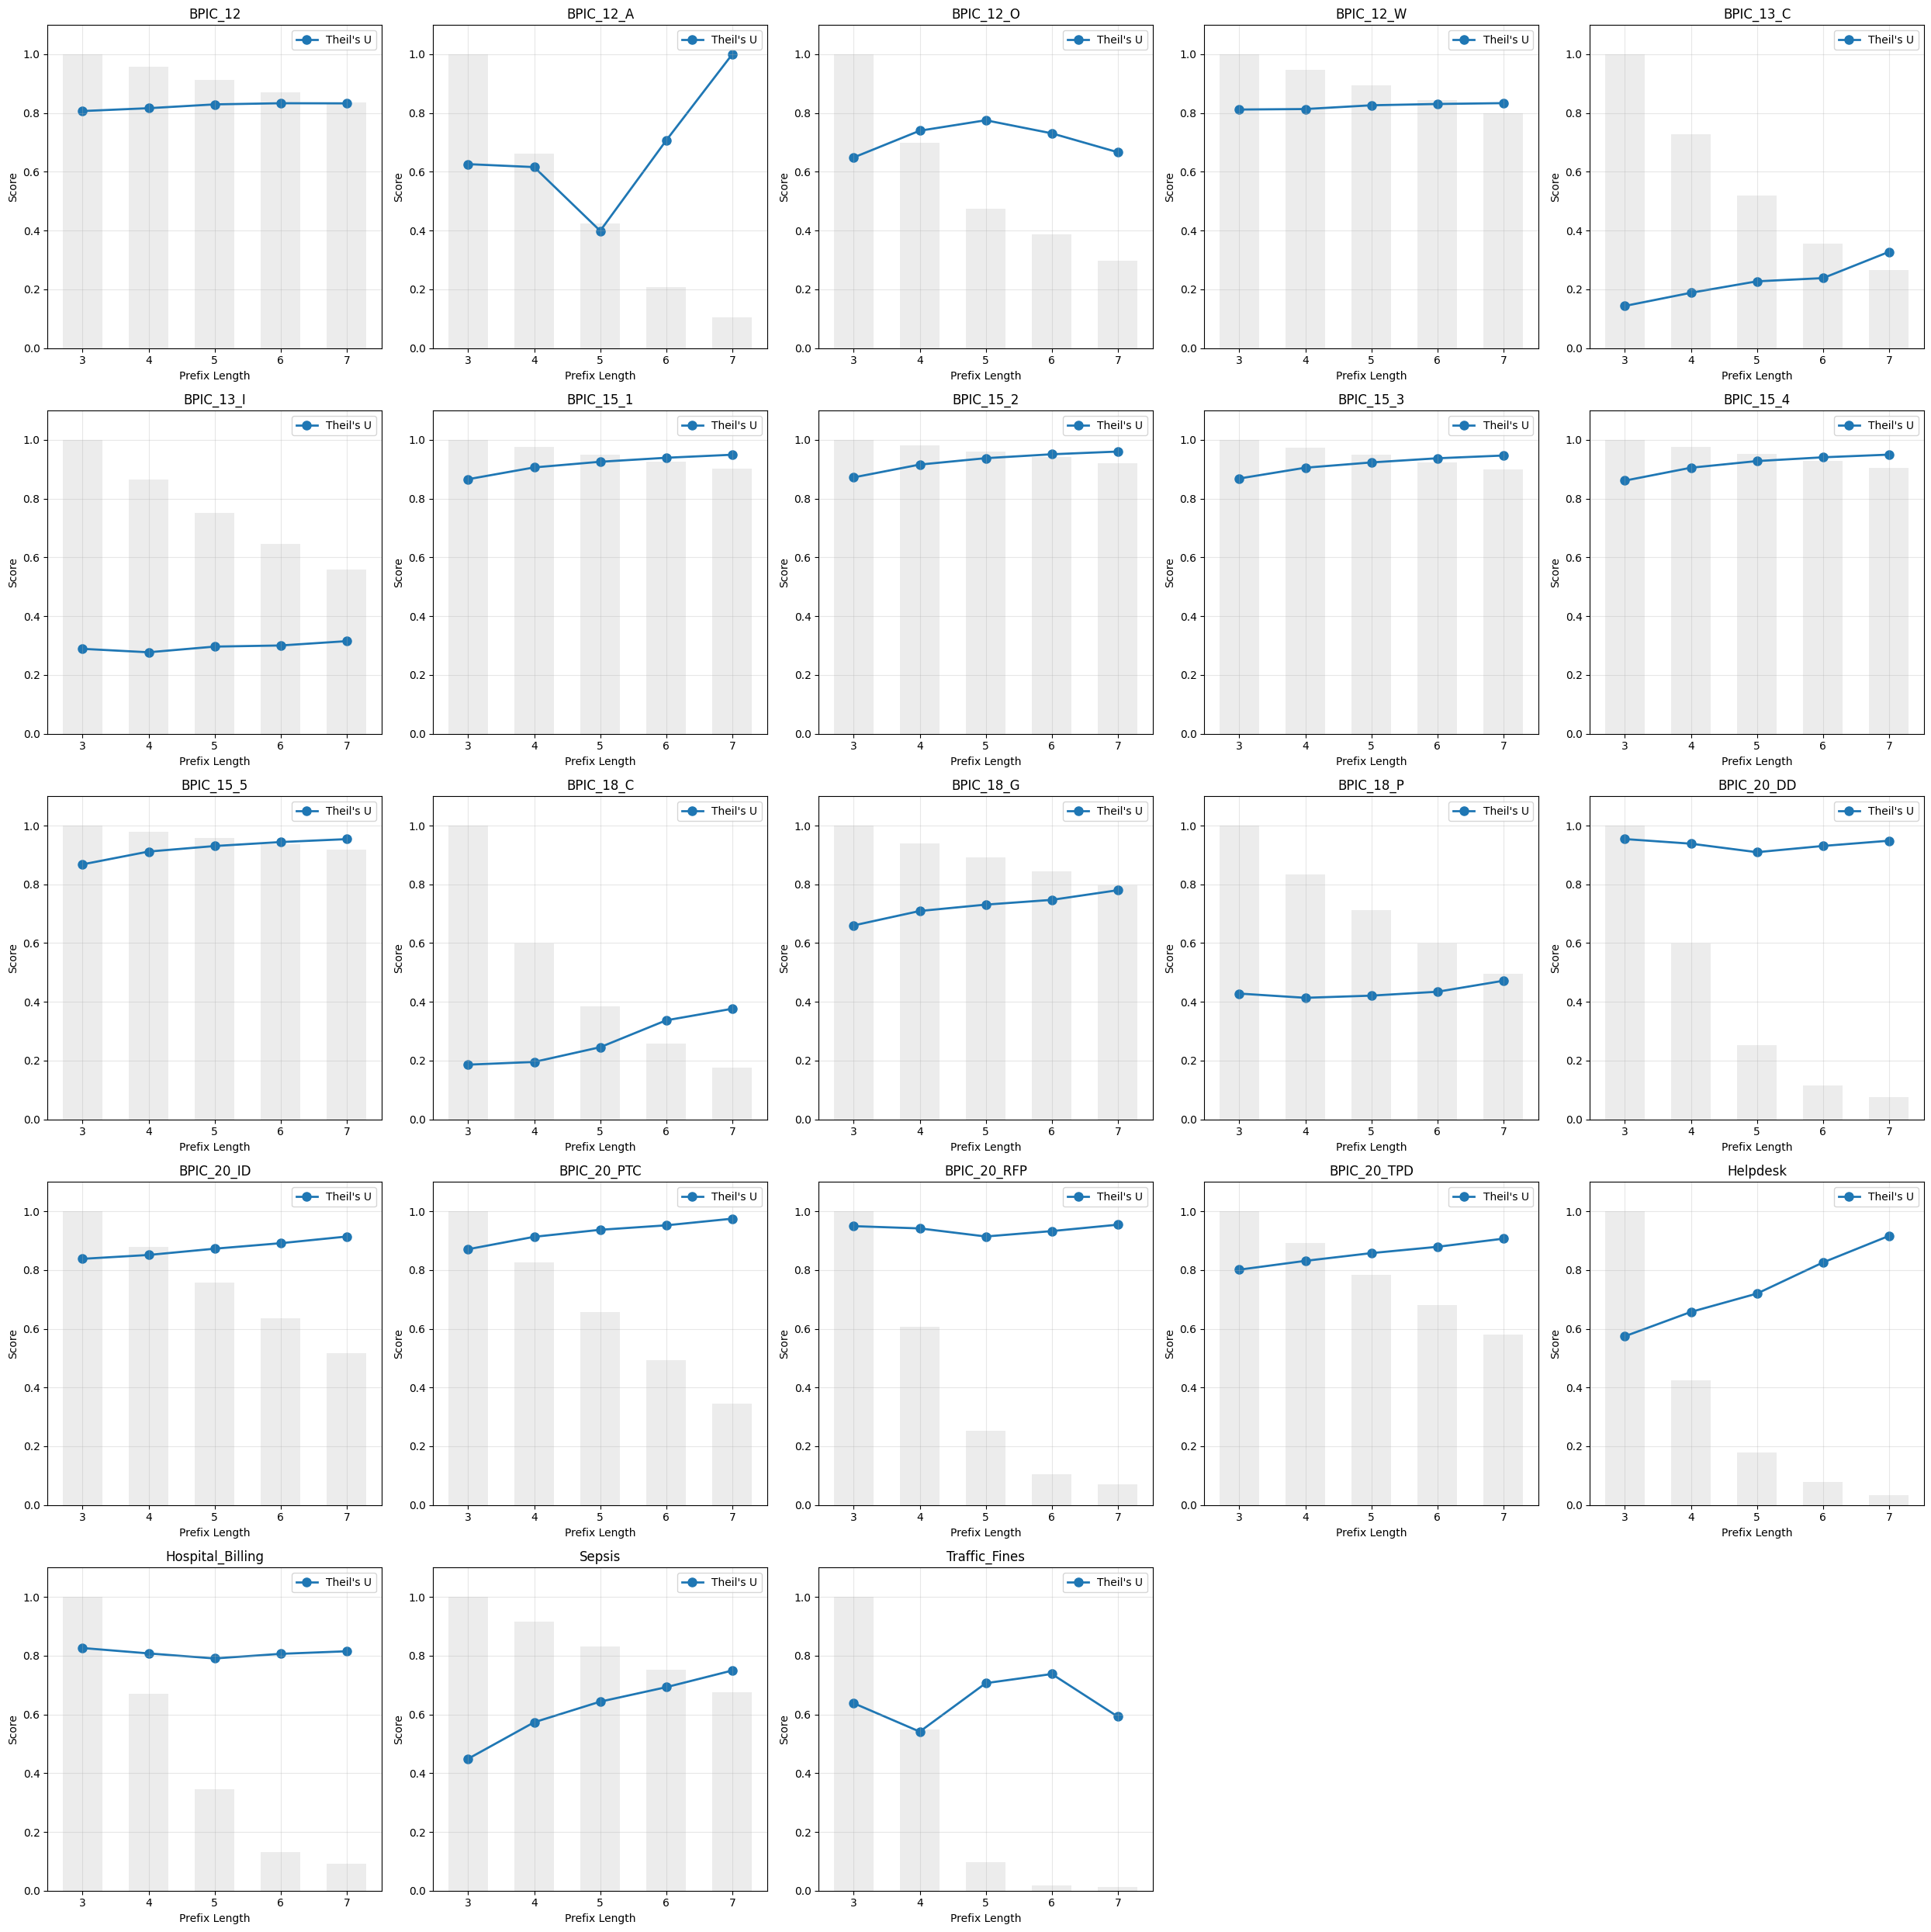

In [114]:
u_values = get_u_values()
sample_nums = get_samples_nums()

plot_data = {}

sequence_windows = sorted(u_values.columns)
for dataset_name in sorted(DATASET_LIST):
    if dataset_name not in u_values.index:
        continue

    u_vals = [u_values.loc[dataset_name, w] for w in sequence_windows]

    plot_data[dataset_name] = {
        'prefix_lens': sequence_windows,
        'u_vals': u_vals,
    }

plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=['u_vals'],
    x_label='Prefix Length',
    y_labels=["Theil's U"],
    samples_df=sample_nums,
)

### N-Gram Analysis

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

from utils.streaming.factories import (
    create_dataset,
    create_model,
    create_pipeline,
    create_transformer,
)


def first_prediction_event_n(predictions_df: pd.DataFrame) -> float:
    """Return first event_n where model outputs a prediction."""
    pred_mask = pd.notna(predictions_df['y_pred'])

    if 'n_pred' in predictions_df.columns:
        pred_mask &= predictions_df['n_pred'] >= 1

    first_event = predictions_df.loc[pred_mask, 'event_n'].min()
    return first_event


def get_prefix_len_prediction_path(dataset_name, prefix_len):
    pred_id = PREFIX_LEN_PREDICTIONS_DICT.get(dataset_name, {}).get(str(prefix_len), '')
    if not pred_id:
        return ''
    return PREFIX_LEN_BASE_FOLDER / pred_id / 'results.csv'


def get_ngram_prediction_path(dataset_name, prefix_len):
    pred_id = NGRAM_PREDICTIONS_DICT.get(dataset_name, {}).get(str(prefix_len), '')
    if not pred_id:
        return ''
    return N_GRAM_BASE_FOLDER / pred_id / 'results.csv'


def compute_prefix_metrics(pred_path, prefix_len, start_event_num=0):
    pred_df = pd.read_csv(pred_path, low_memory=False)

    pred_df = pred_df[pd.notna(pred_df['y_pred'])]

    pred_df = pred_df[pred_df['event_n'] >= start_event_num]

    pred_df = pred_df[pred_df['prefix_len'] > prefix_len]

    if pred_df.empty:
        return {'accuracy': 0.0, 'macro_f1': 0.0}

    y_true = pred_df['y_true']
    y_pred = pred_df['y_pred']

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
    }

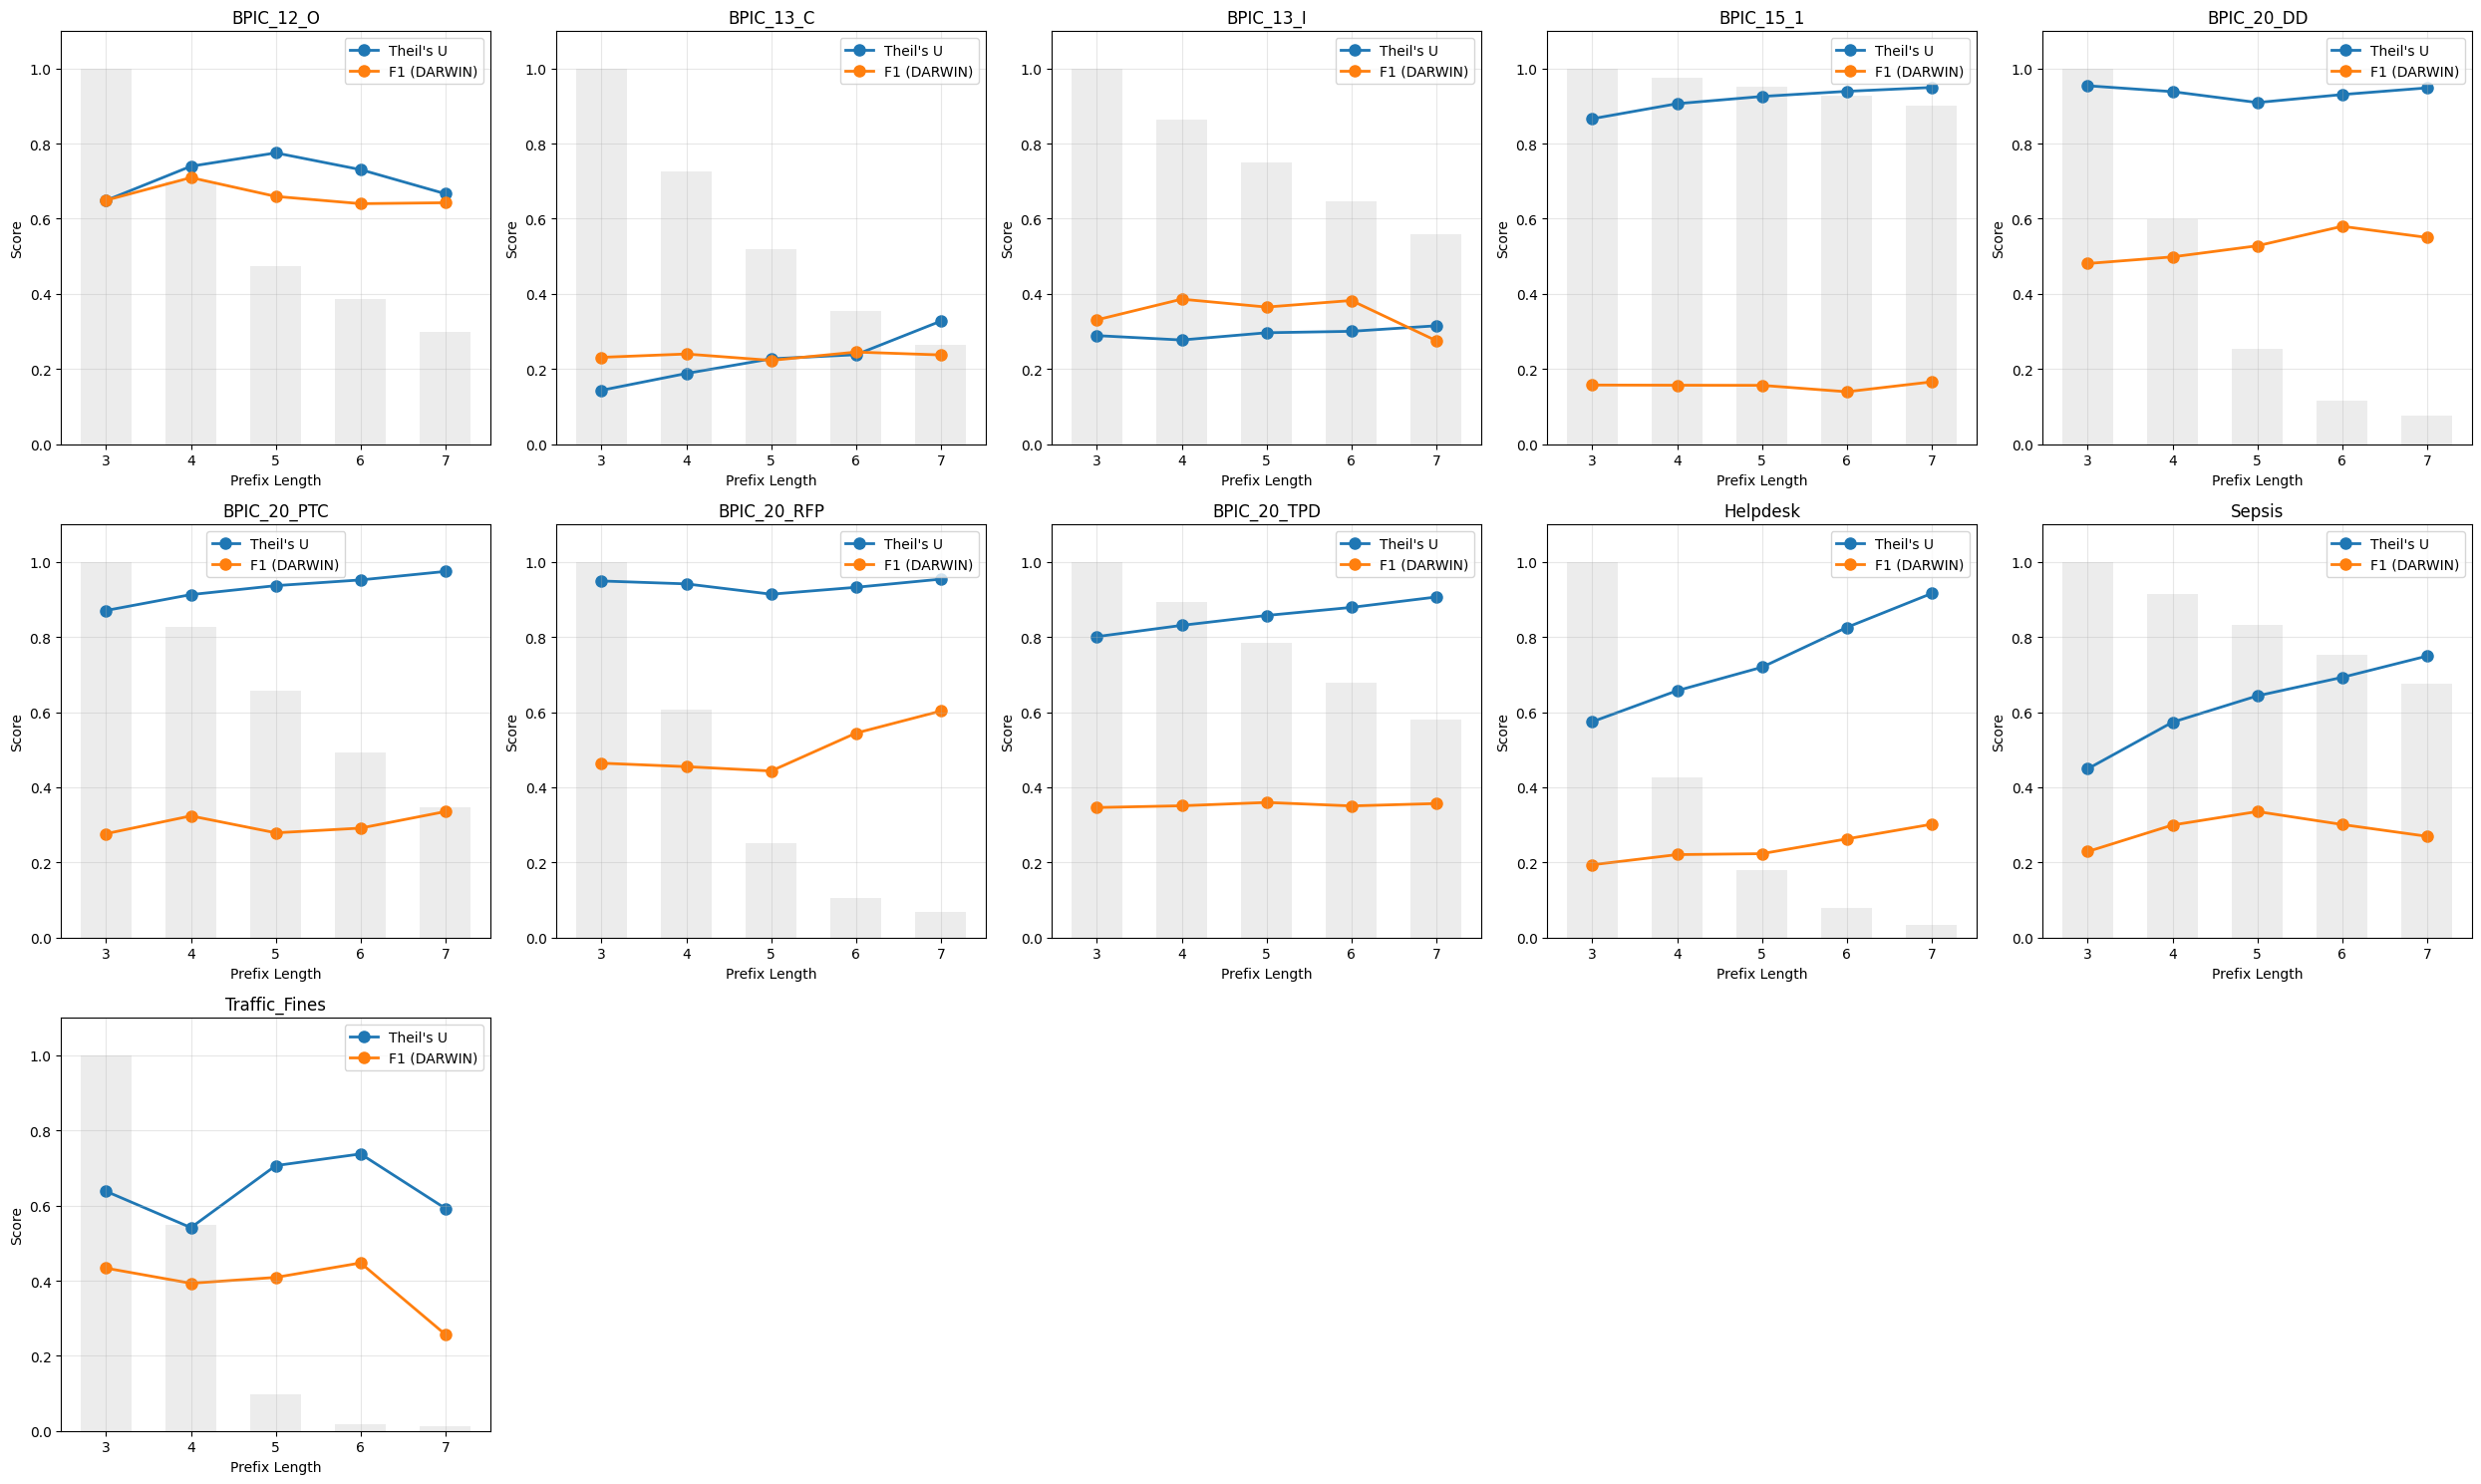

In [197]:
u_values = get_u_values()
sample_nums = get_samples_nums()

plot_data = {}

for dataset_name, dataset_dict in PREFIX_LEN_PREDICTIONS_DICT.items():
    f1_scores = []
    u_vals = []
    prefix_lens = []

    start_event_num = START_EVENTS.get(dataset_name, 0)
    if start_event_num == 0:
        print(f'{dataset_name}: start event is not defined')

    for prefix_len_str in sorted(dataset_dict.keys(), key=int):
        prefix_len = int(prefix_len_str)

        pred_path = get_prefix_len_prediction_path(dataset_name, prefix_len)
        if not (pred_path and pred_path.exists()):
            continue
        if dataset_name not in u_values.index or prefix_len not in u_values.columns:
            continue

        prefix_metrics = compute_prefix_metrics(
            pred_path, prefix_len=prefix_len, start_event_num=start_event_num
        )

        prefix_lens.append(prefix_len)
        u_vals.append(u_values.loc[dataset_name, prefix_len])
        f1_scores.append(prefix_metrics['macro_f1'])

    if prefix_lens:
        plot_data[dataset_name] = {
            'prefix_lens': prefix_lens,
            'f1_scores': f1_scores,
            'u_vals': u_vals,
        }

plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=['u_vals', 'f1_scores'],
    x_label='Prefix Length',
    y_labels=["Theil's U", 'F1 (DARWIN)'],
    samples_df=sample_nums,
)

In [ ]:
metric = 'macro_f1'

task_cfg = {
    'type': 'next_activity',
    'mode': 'predict_and_learn',
}
transformer_cfg = {'type': 'darwin'}

ngram_results = defaultdict(dict)

for dataset_name in DATASET_LIST:
    dataset_cfg = {
        'source': 'log',
        'dataset_path': f'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/raw/{dataset_name}.xes',
        'terminator': {'type': 'oracle'},
    }

    dataset_kwargs, source, terminator, allowed_events = create_dataset(dataset_cfg)

    print(dataset_name)

    for prefix_length in [3, 4, 5, 6, 7]:
        model_cfg = {
            'type': 'ngram_classifier',
            'params': {'sequence_window': prefix_length},
        }

        model = create_model(model_cfg)
        transformer = create_transformer(transformer_cfg)

        pipeline = create_pipeline(
            task_cfg,
            model=model,
            transformer=transformer,
            terminator=terminator,
            source_mode=source,
        )

        results_df, model, elapsed_time = pipeline.run(**dataset_kwargs)

        folder_path = f'{dataset_name}_prefix_{prefix_length}'
        save_path = N_GRAM_BASE_FOLDER / folder_path / 'results.csv'

        os.makedirs(save_path.parent, exist_ok=True)

        results_df.to_csv(save_path, index=False)

        ngram_results[dataset_name][prefix_length] = folder_path

        metric_value = results_df.iloc[-1][metric]

        print(f'Window {prefix_length}: {metric_value:.4f}')

    print('====' * 30)

json.dump(ngram_results, N_GRAMS_JSON_PATH.open('w'), indent=4)

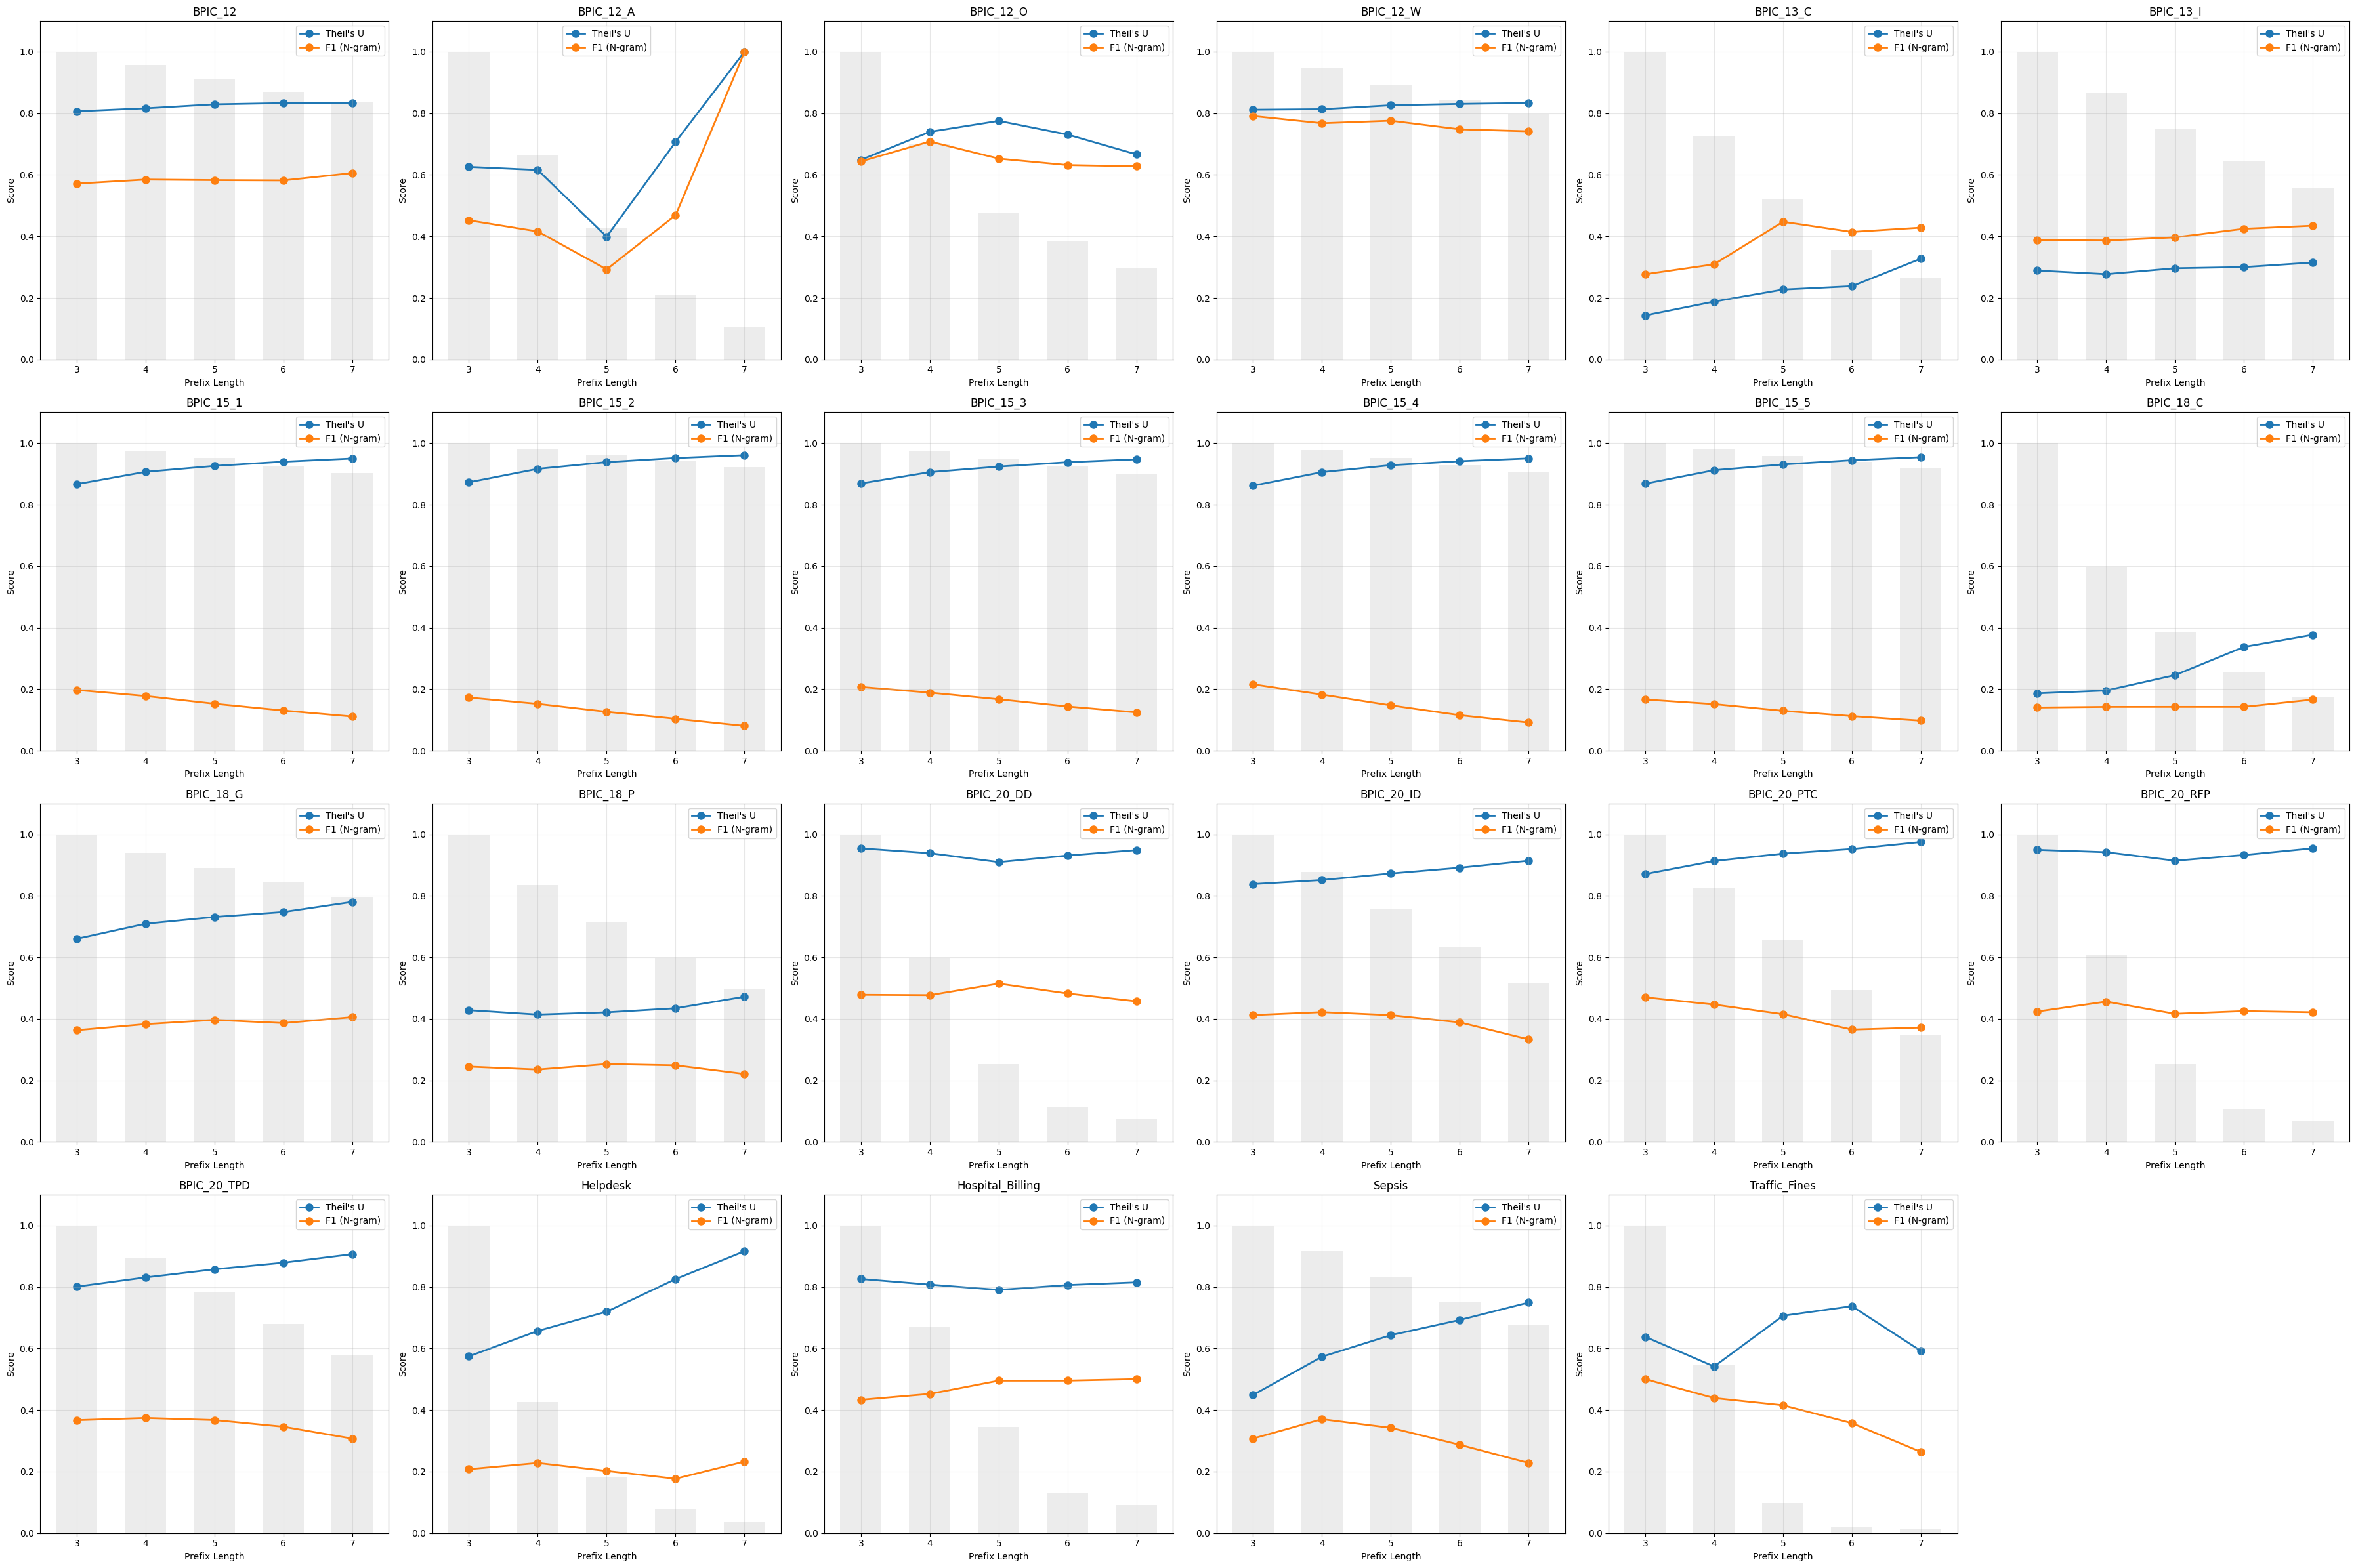

In [237]:
u_values = get_u_values()
sample_nums = get_samples_nums()

plot_data = {}

for dataset_name, dataset_dict in NGRAM_PREDICTIONS_DICT.items():
    f1_scores = []
    u_vals = []
    prefix_lens = []

    for prefix_len_str in sorted(dataset_dict.keys(), key=int):
        prefix_len = int(prefix_len_str)

        pred_path = get_ngram_prediction_path(dataset_name, prefix_len)
        if not (pred_path and pred_path.exists()):
            continue
        if dataset_name not in u_values.index or prefix_len not in u_values.columns:
            continue

        prefix_metrics = compute_prefix_metrics(
            pred_path, prefix_len=prefix_len, start_event_num=0
        )

        prefix_lens.append(prefix_len)
        u_vals.append(u_values.loc[dataset_name, prefix_len])
        f1_scores.append(prefix_metrics['macro_f1'])

    if prefix_lens:
        best_idx = int(np.argmax(f1_scores))
        plot_data[dataset_name] = {
            'prefix_lens': prefix_lens,
            'f1_scores': f1_scores,
            'u_vals': u_vals,
            'best_window': prefix_lens[best_idx],
            'best_score': f1_scores[best_idx],
        }

plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=['u_vals', 'f1_scores'],
    x_label='Prefix Length',
    y_labels=["Theil's U", 'F1 (N-gram)'],
    samples_df=sample_nums,
)

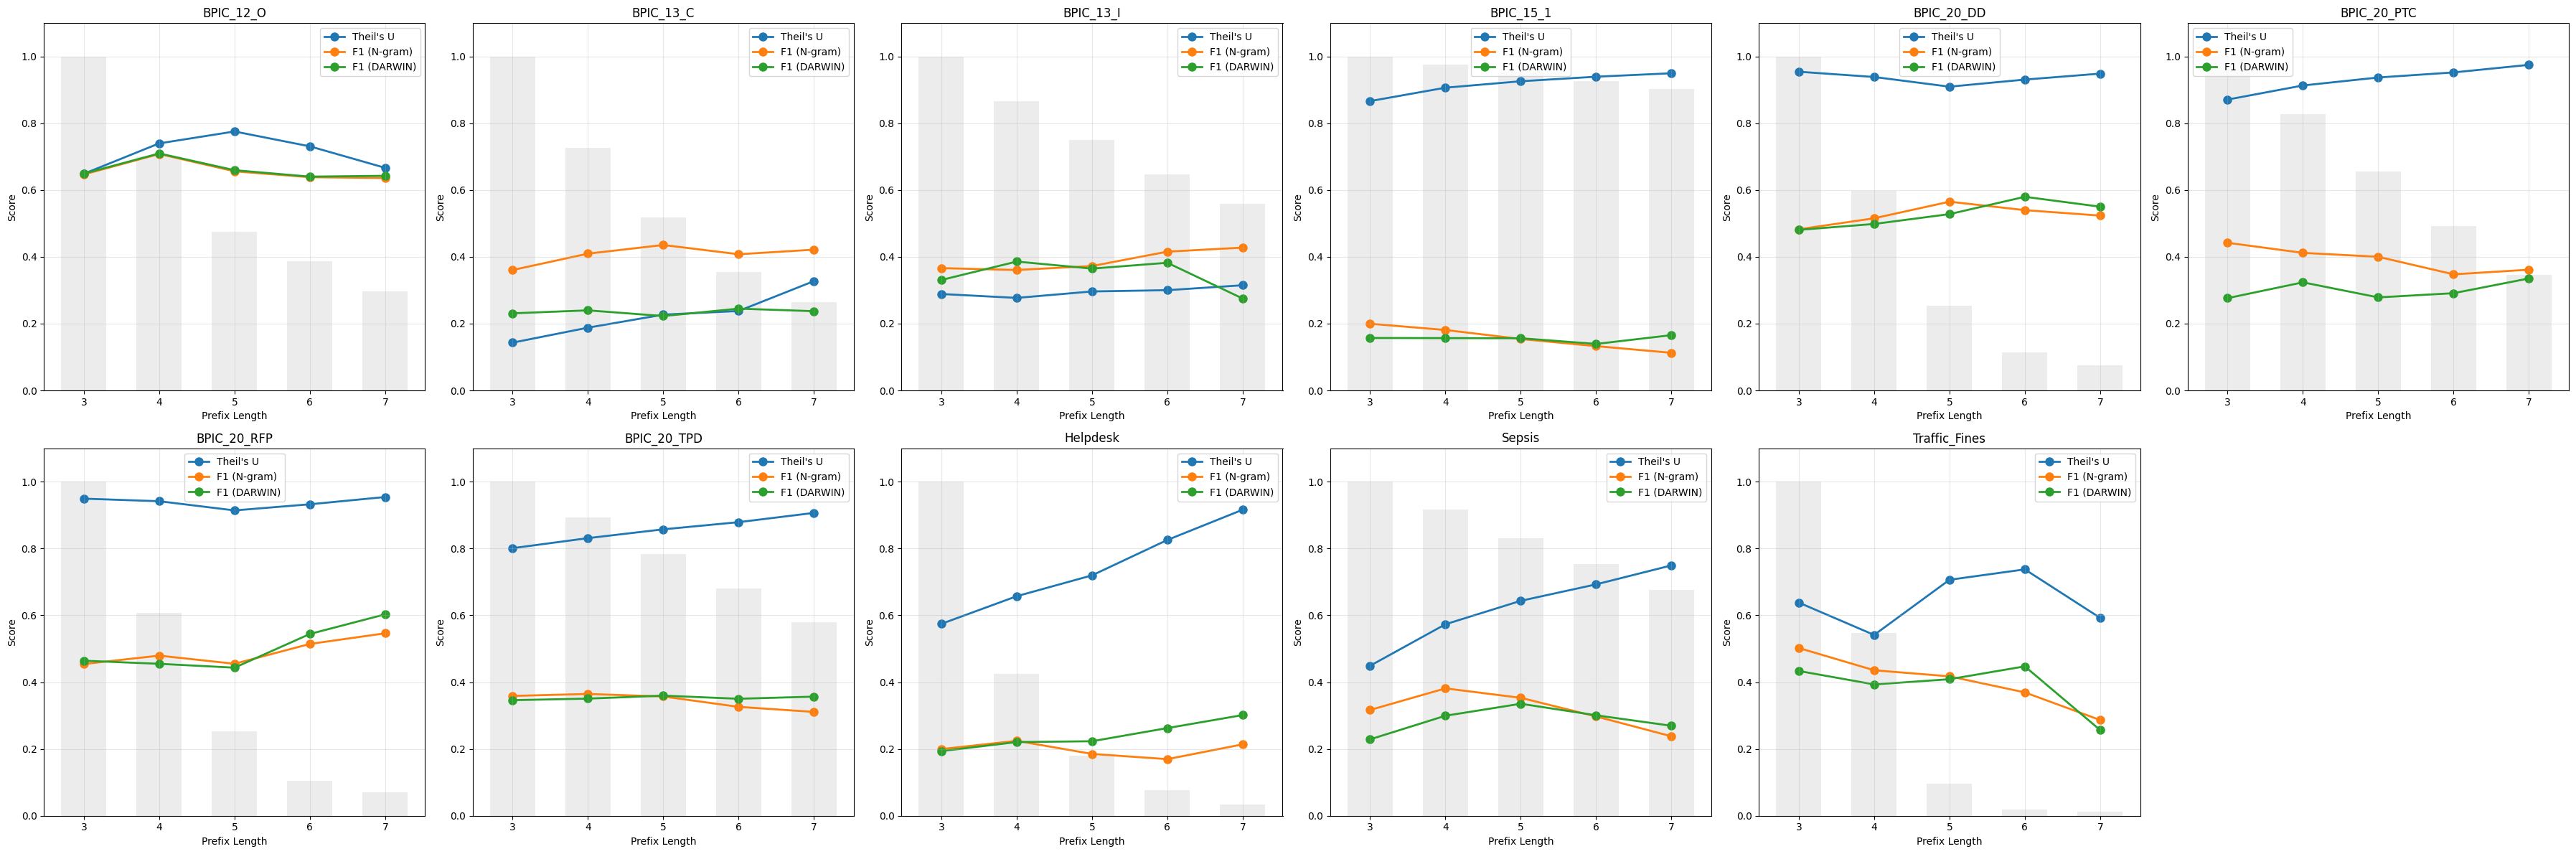

In [220]:
u_values = get_u_values()
sample_nums = get_samples_nums()

plot_data = {}

for dataset_name, dataset_dict in PREFIX_LEN_PREDICTIONS_DICT.items():
    if dataset_name not in u_values.index:
        continue

    if dataset_name not in NGRAM_PREDICTIONS_DICT:
        continue

    n_gram_f1_scores = []
    model_f1_scores = []
    u_vals = []
    prefix_lens = []

    start_event_num = START_EVENTS.get(dataset_name, 0)
    if start_event_num == 0:
        print(f'{dataset_name}: start event is not defined (using 0)')

    for prefix_len in sorted(dataset_dict.keys()):
        prefix_len = int(prefix_len)

        ngram_path = get_ngram_prediction_path(dataset_name, prefix_len)
        if ngram_path and ngram_path.exists():
            ngram_metrics = compute_prefix_metrics(
                ngram_path, prefix_len=prefix_len, start_event_num=start_event_num
            )
            ngram_f1 = ngram_metrics['macro_f1']
        else:
            ngram_f1 = np.nan

        darwin_path = get_prefix_len_prediction_path(dataset_name, prefix_len)
        if darwin_path and darwin_path.exists():
            darwin_metrics = compute_prefix_metrics(
                darwin_path, prefix_len=prefix_len, start_event_num=start_event_num
            )
            darwin_f1 = darwin_metrics['macro_f1']
        else:
            darwin_f1 = np.nan

        prefix_lens.append(prefix_len)
        u_vals.append(u_values.loc[dataset_name, prefix_len])
        n_gram_f1_scores.append(ngram_f1)
        model_f1_scores.append(darwin_f1)

    if prefix_lens:
        plot_data[dataset_name] = {
            'prefix_lens': prefix_lens,
            'n_gram_f1_scores': n_gram_f1_scores,
            'model_f1_scores': model_f1_scores,
            'u_vals': u_vals,
        }

plot_dataset_grid(
    plot_data,
    x_var='prefix_lens',
    y_vars=['u_vals', 'n_gram_f1_scores', 'model_f1_scores'],
    x_label='Prefix Length',
    y_labels=["Theil's U", 'F1 (N-gram)', 'F1 (DARWIN)'],
    samples_df=sample_nums,
)

### Symbolic Entropy

The Logic: If a specific prefix (e.g., "Order $\rightarrow$ Pay") is always followed by "Ship," its conditional entropy is zero. If it’s followed by 10 different things, entropy is high

### Friedman and Nemenyi test

#### DARWIN vs Classic Online

In [11]:
# DARWIN vs Classic Online ML significance test

metric = 'macro_f1'
order = ('darwin', 'aht', 'arf', 'srp')

data = {
    'BPIC_20_DD': (0.425, 0.397, 0.402, 0.415),
    'BPIC_20_TPD': (0.296, 0.291, 0.338, 0.341),
    'BPIC_20_RFP': (0.334, 0.353, 0.351, 0.360),
    'BPIC_20_ID': (0.387, 0.373, 0.401, 0.414),
    'BPIC_20_PTC': (0.411, 0.403, 0.451, 0.457),
    'Helpdesk': (0.308, 0.285, 0.306, 0.299),
    'BPIC_13_C': (0.424, 0.234, 0.371, 0.397),
    'BPIC_13_I': (0.520, 0.419, 0.453, 0.391),
    'BPIC_12': (0.675, 0.452, 0.637, 0.644),
    'BPIC_18_G': (0.362, 0.361, 0.402, 0.390),
    'BPIC_18_P': (0.348, 0.304, 0.341, 0.336),
    'BPIC_18_C': (0.484, 0.446, 0.482, 0.469),
}

comparison_table_df = (
    pd.DataFrame.from_dict(data, orient='index', columns=list(order))
    .astype(float)
    .sort_index()
)

comparison_table_df.columns = pd.MultiIndex.from_tuples(
    [(metric, col) for col in comparison_table_df.columns],
    names=['metric', 'model'],
)

In [12]:
NEXT_ACTIVITY_BASELINE_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/baseline.csv'

metric = 'macro_f1'
# metric = 'accuracy'
target_model = 'darwin'
models = [
    'darwin',
    # 'darwin_transformer',
    'aht',
    'arf',
    'srp',
]

results_df = pd.read_csv(NEXT_ACTIVITY_BASELINE_PATH)
dataset_names = results_df.pop('dataset_name')

results_df.columns = pd.MultiIndex.from_tuples(
    [ast.literal_eval(col) for col in results_df.columns],
    names=['metric', 'model'],
)

results_df.insert(0, 'dataset_name', dataset_names)

wanted_cols = pd.MultiIndex.from_tuples(
    [(metric, model_name) for model_name in models],
    names=['metric', 'model'],
)

comparison_table_df = results_df.set_index('dataset_name').loc[:, wanted_cols]

comparison_table_df

metric        macro_f1                     
model           darwin    aht    arf    srp
dataset_name                               
BPIC_12          0.606  0.608  0.584  0.542
BPIC_13_C        0.418  0.401  0.454  0.454
BPIC_13_I        0.432  0.270  0.326  0.318
BPIC_15_1        0.183  0.206  0.247  0.250
BPIC_18_C        0.475  0.460  0.416  0.397
BPIC_18_G        0.332  0.353  0.429  0.401
BPIC_18_P        0.412  0.347  0.308  0.287
BPIC_20_DD       0.400  0.443  0.391  0.461
BPIC_20_ID       0.433  0.396  0.417  0.414
BPIC_20_PTC      0.358  0.451  0.495  0.462
BPIC_20_RFP      0.400  0.384  0.370  0.407
BPIC_20_TPD      0.366  0.350  0.262  0.240
Helpdesk         0.241  0.231  0.289  0.279
Sepsis           0.424  0.375  0.385  0.358
Traffic_Fines    0.575  0.584  0.376  0.367

In [13]:
scores_df = comparison_table_df.xs(metric, axis=1, level='metric')[models].dropna()

# 1) Friedman test
friedman_stat, friedman_p = stats.friedmanchisquare(*scores_df.to_numpy().T)

print(f'Friedman chi-square = {friedman_stat:.4f}, p = {friedman_p:.6f}')

Friedman chi-square = 1.8322, p = 0.607950


In [14]:
# 2) Nemenyi post-hoc
nemenyi_pvals = sp.posthoc_nemenyi_friedman(scores_df)
nemenyi_pvals.columns = scores_df.columns
nemenyi_pvals.index = scores_df.columns

# Average ranks (lower rank is better)
avg_ranks = scores_df.rank(axis=1, ascending=False).mean().sort_values()

print('\nAverage ranks:')
print(avg_ranks)

print('\nNemenyi p-values:')
display(nemenyi_pvals)

print(f'\n{target_model} vs others:')
display(nemenyi_pvals.loc[target_model, models])


Average ranks:
model
darwin    2.200000
arf       2.366667
srp       2.700000
aht       2.733333
dtype: float64

Nemenyi p-values:


model,darwin,aht,arf,srp
model,,,,
darwin,1.000000,0.670092,0.984850,0.713509
aht,0.670092,1.000000,0.864541,0.999873
arf,0.984850,0.864541,1.000000,0.894326
srp,0.713509,0.999873,0.894326,1.000000



darwin vs others:


model
darwin    1.000000
aht       0.670092
arf       0.984850
srp       0.713509
Name: darwin, dtype: float64

Critical Difference (CD): 1.2111


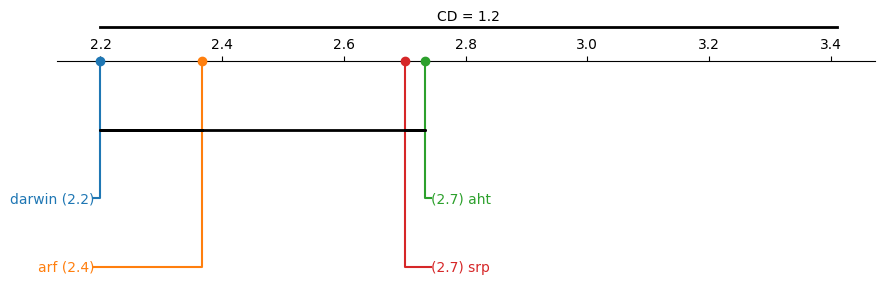

In [15]:
# 3. Critical Difference (CD)
alpha = 0.05

k = len(scores_df.columns)
N = len(scores_df)
q_alpha = stats.studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)

cd_value = q_alpha * np.sqrt((k * (k + 1)) / (6 * N))
print(f'Critical Difference (CD): {cd_value:.4f}')

plt.figure(figsize=(9, 3))

sp.critical_difference_diagram(
    ranks=avg_ranks, sig_matrix=nemenyi_pvals, cd=cd_value, alpha=alpha
)

plt.tight_layout()
plt.show()

#### One-hot vs Word2Vec

In [22]:
metric = 'macro_f1'
order = ['one_hot', 'word2vec']

ENCODING_COMPARISON_PATH = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/results/next_activity/encoding_comparison.csv'

results_df = pd.read_csv(ENCODING_COMPARISON_PATH)
dataset_names = results_df.pop('dataset_name')

results_df.columns = pd.MultiIndex.from_tuples(
    [ast.literal_eval(col) for col in results_df.columns],
    names=['metric', 'encoding'],
)

results_df.insert(0, 'dataset_name', dataset_names)

wanted_cols = pd.MultiIndex.from_tuples(
    [(metric, encoding) for encoding in order],
    names=['metric', 'encoding'],
)

comparison_table_df = results_df.set_index('dataset_name').loc[:, wanted_cols]

comparison_table_df

metric        macro_f1         
encoding       one_hot word2vec
dataset_name                   
BPIC_12          0.610    0.606
BPIC_13_C        0.318    0.418
BPIC_13_I        0.419    0.432
BPIC_15_1        0.168    0.183
BPIC_18_C        0.434    0.475
BPIC_18_G        0.381    0.332
BPIC_18_P        0.418    0.412
BPIC_20_DD       0.395    0.400
BPIC_20_ID       0.422    0.433
BPIC_20_PTC      0.397    0.358
BPIC_20_RFP      0.376    0.400
BPIC_20_TPD      0.367    0.366
Helpdesk         0.262    0.241
Sepsis           0.428    0.424
Traffic_Fines    0.563    0.575

In [24]:
one_hot_scores = scores_df['one_hot'].to_numpy()
word2vec_scores = scores_df['word2vec'].to_numpy()

# Wilcoxon signed-rank test
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(one_hot_scores, word2vec_scores)

print(f'Wilcoxon statistic = {wilcoxon_stat:.4f}, p-value = {wilcoxon_p:.6f}')

Wilcoxon statistic = 47.0000, p-value = 0.460211
